# 🔬 Tensor Parallelism: Hands-On Tutorial

**A complete, runnable demonstration of Tensor Parallelism applied to an LLM architecture.**

This notebook:
1. Implements a GPT-style transformer model from scratch
2. Implements Column-Parallel and Row-Parallel linear layers from scratch
3. Benchmarks **without TP** (single GPU) vs **with TP** (multi-GPU)
4. Compares memory usage, throughput, and verifies numerical correctness

**Requirements:** 2+ NVIDIA GPUs (RunPod, Lambda, etc.)

---

## Part 0: Environment Setup

In [1]:
!nvidia-smi --query-gpu=index,name,memory.total --format=csv,noheader
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Number of GPUs: {torch.cuda.device_count()}')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} '
          f'({torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB)')

0, NVIDIA A10G, 23028 MiB
1, NVIDIA A10G, 23028 MiB
2, NVIDIA A10G, 23028 MiB
3, NVIDIA A10G, 23028 MiB
PyTorch version: 2.8.0+cu128
CUDA available: True
Number of GPUs: 4
  GPU 0: NVIDIA A10G (23.6 GB)
  GPU 1: NVIDIA A10G (23.6 GB)
  GPU 2: NVIDIA A10G (23.6 GB)
  GPU 3: NVIDIA A10G (23.6 GB)


In [2]:
%env CUDA_VISIBLE_DEVICES=0,1

env: CUDA_VISIBLE_DEVICES=0,1


In [3]:
import sys
sys.path.insert(0, "src")

## Part 1: The Model — A GPT-Style Transformer

We define a standard transformer decoder with:
- `d_model = 512`, `n_heads = 8`, `d_head = 64`
- `d_ff = 2048` (4x expansion), `n_layers = 6`, `vocab_size = 10000`

Small enough to run quickly but large enough to see real differences.

In [4]:
from IPython.display import Code

Code(filename="src/model_gpt.py", language="python")

"""Standard (non-parallelized) GPT-style transformer model.

A minimal GPT decoder used as the baseline for tensor-parallelism experiments.
Single-GPU benchmark - no distributed communication.
"""

import argparse
import json
import logging
import math
import os
import time

#from rich.logging import RichHandler

import torch
import torch.nn as nn
import torch.nn.functional as F

from utils import count_parameters, get_gpu_memory_mb, get_gpu_peak_memory_mb

logger = logging.getLogger(__name__)

# ================================================================
# Default Model & Benchmark Constants
# ================================================================

DEFAULT_D_MODEL = 512  # hidden dimension (embedding size)
DEFAULT_N_HEADS = 8  # number of attention heads
DEFAULT_D_FF = 2048  # feed-forward intermediate dimension (4x D_MODEL)
DEFAULT_N_LAYERS = 6  # number of transformer blocks
DEFAULT_VOCAB_SIZE = 10_000
DEFAULT_MAX_SEQ_LEN = 512

DEFAULT_BATCH_SIZE = 8
DEFAULT_SEQ_LEN = 256
DEFAULT_NUM_WARMUP = 3
DEFAULT_NUM_BENCHMARK = 10


# ================================================================
# Standard Multi-Head Attention
# ================================================================


class StandardAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, bias: bool = False):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.scale = 1.0 / math.sqrt(self.d_head)

        self.W_q = nn.Linear(d_model, d_model, bias=bias)
        self.W_k = nn.Linear(d_model, d_model, bias=bias)
        self.W_v = nn.Linear(d_model, d_model, bias=bias)
        self.W_o = nn.Linear(d_model, d_model, bias=bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        attn = (Q @ K.transpose(-2, -1)) * self.scale
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        attn = attn.masked_fill(mask, float("-inf"))
        attn = F.softmax(attn, dim=-1)

        out = (attn @ V).transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_o(out)


# ================================================================
# Standard FFN (feed-forward network)
# ================================================================


class StandardFFN(nn.Module):
    def __init__(self, d_model: int, d_ff: int, bias: bool = True):
        super().__init__()
        self.W1 = nn.Linear(d_model, d_ff, bias=bias)
        self.W2 = nn.Linear(d_ff, d_model, bias=bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.W2(F.gelu(self.W1(x)))


# ================================================================
# GPT Transformer Block
# ================================================================


class StandardTransformerBlock(nn.Module):
    def __init__(
        self,
        d_model: int,
        n_heads: int,
        d_ff: int,
        attn_bias: bool = False,
        ffn_bias: bool = True,
    ):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = StandardAttention(d_model, n_heads, bias=attn_bias)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = StandardFFN(d_model, d_ff, bias=ffn_bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


# ================================================================
# Full GPT Model
# ================================================================


class StandardGPT(nn.Module):
    def __init__(
        self,
        d_model: int = DEFAULT_D_MODEL,
        n_heads: int = DEFAULT_N_HEADS,
        d_ff: int = DEFAULT_D_FF,
        n_layers: int = DEFAULT_N_LAY

Let's verify the model works:

In [5]:
from model_gpt import *

model = StandardGPT().cuda()
n_params = count_parameters(model)
print(f'Model parameters: {n_params:,} ({n_params * 2 / 1e6:.1f} MB in BF16)')
print(f'Architecture: d_model={DEFAULT_D_MODEL}, n_heads={DEFAULT_N_HEADS}, d_ff={DEFAULT_D_FF}, layers={DEFAULT_N_LAYERS}')
print(f'\nBlock 0 parameter breakdown:')
for name, param in model.named_parameters():
    if 'blocks.0.' in name:
        print(f'  {name:40s} {str(list(param.shape)):20s} {param.numel():>8,}')

test_input = torch.randint(0, DEFAULT_VOCAB_SIZE, (2, 32)).cuda()
with torch.no_grad():
    out = model(test_input)
print(f'\nForward pass OK: {list(test_input.shape)} -> {list(out.shape)}')
del model; torch.cuda.empty_cache()

Model parameters: 29,405,184 (58.8 MB in BF16)
Architecture: d_model=512, n_heads=8, d_ff=2048, layers=6

Block 0 parameter breakdown:
  blocks.0.ln1.weight                      [512]                     512
  blocks.0.ln1.bias                        [512]                     512
  blocks.0.attn.W_q.weight                 [512, 512]            262,144
  blocks.0.attn.W_k.weight                 [512, 512]            262,144
  blocks.0.attn.W_v.weight                 [512, 512]            262,144
  blocks.0.attn.W_o.weight                 [512, 512]            262,144
  blocks.0.ln2.weight                      [512]                     512
  blocks.0.ln2.bias                        [512]                     512
  blocks.0.ffn.W1.weight                   [2048, 512]          1,048,576
  blocks.0.ffn.W1.bias                     [2048]                  2,048
  blocks.0.ffn.W2.weight                   [512, 2048]          1,048,576
  blocks.0.ffn.W2.bias                     [512]            

## Part 2: Baseline - No Tensor Parallelism (Single GPU)

Run the full model on a single GPU and measure memory + throughput.

In [6]:
!python src/model_gpt.py

Standard GPT benchmark (single GPU)
d_model=512, n_heads=8, d_ff=2048, n_layers=6, vocab=10000
Model params: 29,405,184
Model size: 113.11 MB
params: 29,405,184 | model: 113.1 MB | peak: 1157.0 MB
  Model GPT - No parallelism - 1 GPU
  Params Per Gpu              29,405,184
  Mem Model Mb                    113.11
  Mem Peak Mb                    1157.03
  Fwd Ms                           10.30
  Bwd Ms                           18.35
  Step Ms                          33.71
  Tokens Per Sec                60753.30
  Loss                              7.57


## Part 3: Tensor Parallelism - From Scratch

### Column-Parallel Linear
Split weight **columns** (output dim). Each GPU computes a slice. **No communication.**

### Row-Parallel Linear
Split weight **rows** (input dim). Each GPU computes a partial sum. **All-reduce needed!**

### Pattern in Transformer Block
```
Attention:  W_q, W_k, W_v → Column-Parallel (split heads across GPUs)
            W_o            → Row-Parallel    (combine heads, ALL-REDUCE)

FFN:        W1             → Column-Parallel (split d_ff across GPUs)
            W2             → Row-Parallel    (combine back, ALL-REDUCE)

Communication: 2 all-reduces per transformer block
```

In [7]:
from IPython.display import Code

Code(filename="src/model_gpt_tp.py", language="python")

"""TP GPT-style transformer model.

A minimal GPT decoder with Tensor Parallelism. Weight matrices are sharded
across GPUs using Column-Parallel and Row-Parallel linear layers.

Uses the default process group (all GPUs) for all communication.
"""

import argparse
import json
import logging
import math
import os
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributed as dist

from utils import count_parameters, get_gpu_memory_mb, get_gpu_peak_memory_mb

logger = logging.getLogger(__name__)

# ================================================================
# Default Model & Benchmark Constants
# ================================================================

DEFAULT_D_MODEL = 512  # hidden dimension (embedding size)
DEFAULT_N_HEADS = 8  # number of attention heads
DEFAULT_D_FF = 2048  # feed-forward intermediate dimension (4x D_MODEL)
DEFAULT_N_LAYERS = 6  # number of transformer blocks
DEFAULT_VOCAB_SIZE = 10_000
DEFAULT_MAX_SEQ_LEN = 512

DEFAULT_BATCH_SIZE = 8
DEFAULT_SEQ_LEN = 256
DEFAULT_NUM_WARMUP = 3
DEFAULT_NUM_BENCHMARK = 10


# ================================================================
#  Autograd functions for TP communication
# ================================================================
# _CopyToParallelRegion:     identity forward,   all-reduce backward
#   -> Used before column-parallel layers
# _ReduceFromParallelRegion: all-reduce forward, identity backward
#   -> Used after row-parallel layers


class _CopyToParallelRegion(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x: torch.Tensor) -> torch.Tensor:
        return x

    @staticmethod
    def backward(ctx, grad: torch.Tensor):
        dist.all_reduce(grad, op=dist.ReduceOp.SUM)
        return grad


class _ReduceFromParallelRegion(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x: torch.Tensor) -> torch.Tensor:
        dist.all_reduce(x, op=dist.ReduceOp.SUM)
        return x

    @staticmethod
    def backward(ctx, grad: torch.Tensor):
        return grad


# ================================================================
#  Column-parallel linear
# ================================================================
# Full: (d_out, d_in) -> this GPU: (d_out // N, d_in)
# Input: same on all GPUs -> output: each GPU gets different slice
# No communication in forward!


class ColumnParallelLinear(nn.Module):
    def __init__(self, d_in: int, d_out: int, bias: bool = True) -> None:
        super().__init__()
        ws = dist.get_world_size()
        assert d_out % ws == 0, "d_out must be divisible by world size"
        # F.linear computes x @ W.T, so W is stored as (d_out, d_in) to match PyTorch convention.
        # We shard the output dim: each GPU holds (d_out // ws, d_in).
        self.weight = nn.Parameter(torch.empty(d_out // ws, d_in))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        self.bias = None
        if bias:
            self.bias = nn.Parameter(torch.empty(d_out // ws))
            nn.init.uniform_(self.bias, a=-1 / math.sqrt(d_in), b=1 / math.sqrt(d_in))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = _CopyToParallelRegion.apply(x)
        return F.linear(x, self.weight, self.bias)


# ================================================================
#  Row-parallel linear
# ================================================================
# Full: (d_out, d_in) -> this GPU: (d_out, d_in // N)
# Input: local slice -> output: partial sum, needs all-reduce!


class RowParallelLinear(nn.Module):
    def __init__(self, d_in: int, d_out: int, bias: bool = True) -> None:
        super().__init__()
        ws = dist.get_world_size()
        assert d_in % ws == 0, "d_in must be divisible by world size"
        # F.linear computes x @ W.T, so W is stored as (d_out, d_in) to match PyTorch convention.
        # We shard the input dim: each GPU holds (d_out, d_in // ws).
        self.weight = nn.Parameter(torch.empty(d_out

### Run the TP benchmark

`torchrun` launches one process per GPU. Each sees a different `dist.get_rank()`.
**Adjust `nproc_per_node` to match your GPU count.**

In [8]:
import torch
n_gpus = min(torch.cuda.device_count(), 2)
print(f'Launching with {n_gpus} GPUs...')
!torchrun --nproc_per_node={n_gpus} src/model_gpt_tp.py

Launching with 2 GPUs...
W0404 11:54:51.997000 1539650 torch/distributed/run.py:774] 
W0404 11:54:51.997000 1539650 torch/distributed/run.py:774] *****************************************
W0404 11:54:51.997000 1539650 torch/distributed/run.py:774] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0404 11:54:51.997000 1539650 torch/distributed/run.py:774] *****************************************
TP benchmark: 2 GPUs
d_model=512, n_heads=8, d_ff=2048, n_layers=6, vocab=10000
Each GPU: 4/8 heads, 1024/2048 FFN dim
Model params: 17,401,856 (local), 34,803,712 (total)
Model size: 66.85 MB
[GPU 0] params: 17,401,856 | model: 66.9 MB | peak: 789.4 MB
[GPU 1] params: 17,398,784 | model: 66.8 MB | peak: 789.4 MB
  Model GPT - Tensor parallelism - 2 GPUs
  Params Per Gpu              17,401,856
  Mem Model Mb                     66.85
 

## Part 4: Side-by-Side Comparison

In [10]:
import json

with open('outputs/results_model_gpt.json') as f: no_tp = json.load(f)
with open('outputs/results_model_gpt_tp.json') as f: tp = json.load(f)

ng = tp["num_gpus"]
n_layers = no_tp['n_layers']
p1, p2 = no_tp['params_per_gpu'], tp['params_per_gpu']
m1, m2 = no_tp['mem_model_mb'], tp['mem_model_mb']
pk1, pk2 = no_tp['mem_peak_mb'], tp['mem_peak_mb']
speedup = no_tp['step_ms'] / tp['step_ms']
eff = speedup / ng * 100

print("\n" + "="*74)
print("  TENSOR PARALLELISM: SIDE-BY-SIDE COMPARISON")
print("="*74)
rows = [
    ("Parameters/GPU",     f"{p1:,}",              f"{p2:,}"),
    ("  Reduction",        "---",                   f"{(1-p2/p1)*100:.1f}% fewer"),
    ("---", "", ""),
    ("Model memory (MB)",  f"{m1:.1f}",            f"{m2:.1f}"),
    ("  Reduction",        "---",                   f"{(1-m2/m1)*100:.1f}% less"),
    ("Peak memory (MB)",   f"{pk1:.1f}",           f"{pk2:.1f}"),
    ("  Reduction",        "---",                   f"{(1-pk2/pk1)*100:.1f}% less"),
    ("---", "", ""),
    ("Forward (ms)",       f"{no_tp['fwd_ms']:.2f}",  f"{tp['fwd_ms']:.2f}"),
    ("Backward (ms)",      f"{no_tp['bwd_ms']:.2f}",  f"{tp['bwd_ms']:.2f}"),
    ("Full step (ms)",     f"{no_tp['step_ms']:.2f}",  f"{tp['step_ms']:.2f}"),
    ("  Speedup",          "---",                   f"{speedup:.2f}x"),
    ("  Ideal",            "---",                   f"{ng:.0f}x"),
    ("  Efficiency",       "---",                   f"{eff:.1f}%"),
    ("---", "", ""),
    ("Throughput (tok/s)", f"{no_tp['tokens_per_sec']:,.0f}", f"{tp['tokens_per_sec']:,.0f}"),
    ("Loss",               f"{no_tp['loss']:.4f}",  f"{tp['loss']:.4f}"),
]
print(f"  {'Metric':<28} {'No TP (1 GPU)':>20} {'TP (' + str(ng) + ' GPUs)':>20}")
for label, v1, v2 in rows:
    if label == "---":
        print("  " + "-"*68)
    else:
        print(f"  {label:<28} {v1:>20} {v2:>20}")
print("="*74)

print(f"\n  ANALYSIS:")
print(f"  * Param reduction: {(1-p2/p1)*100:.1f}% (not 50% — LayerNorm + embeddings replicated)")
print(f"  * Peak mem reduction: {(1-pk2/pk1)*100:.1f}% (LN activations still full d_model)")
print(f"  * Speedup: {speedup:.2f}x / {ng}x ideal = {eff:.1f}% efficiency")
print(f"  * Comm overhead: ~{100-eff:.1f}% ({n_layers} layers x 2 all-reduces = {n_layers*2}/step)")


  TENSOR PARALLELISM: SIDE-BY-SIDE COMPARISON
  Metric                              No TP (1 GPU)          TP (2 GPUs)
  Parameters/GPU                         29,405,184           17,401,856
    Reduction                                   ---          40.8% fewer
  --------------------------------------------------------------------
  Model memory (MB)                           113.1                 66.8
    Reduction                                   ---           40.9% less
  Peak memory (MB)                           1157.0                789.4
    Reduction                                   ---           31.8% less
  --------------------------------------------------------------------
  Forward (ms)                                10.30                38.08
  Backward (ms)                               18.35                45.69
  Full step (ms)                              33.71                87.01
    Speedup                                     ---                0.39x
    Idea

## Part 5: Visualizing the Weight Splits

Let's inspect exactly which weights are split vs replicated on each GPU.

In [11]:
from IPython.display import Code

Code(filename="src/inspect_splits.py", language="python")

import argparse
import logging
import os

import torch
import torch.distributed as dist


logger = logging.getLogger(__name__)

MODELS = {
    "gpt": "model_gpt_tp",
    "llama": "model_llama_tp",
}


def classify_param(
    name: str, module_path: str, param: torch.nn.Parameter, ws: int
) -> tuple[list[int], str, bool]:
    """Return (full_shape, note, is_split) for a parameter."""
    full = list(param.shape)
    is_weight = name.endswith("weight")

    if "ColumnParallelLinear" in module_path:
        if is_weight:
            full[0] *= ws
            return full, "col-parallel (d_out sharded)", True
        full[0] *= ws
        return full, "col-parallel bias", True

    if "RowParallelLinear" in module_path:
        if is_weight:
            full[1] *= ws
            return full, "row-parallel (d_in sharded)", True
        return full, "row-parallel bias (rank 0 only)", False

    return full, "replicated (not split)", False


def get_module_class_map(block: torch.nn.Module) -> dict[str, str]:
    """Map parameter prefix -> module class name."""
    result = {}
    for mod_name, mod in block.named_modules():
        cls = type(mod).__name__
        result[mod_name] = cls
    return result


def find_parent_class(param_name: str, class_map: dict[str, str]) -> str:
    """Find the class name of the module that owns a parameter."""
    parts = param_name.rsplit(".", 1)
    if len(parts) == 2:
        mod_prefix = parts[0]
        if mod_prefix in class_map:
            return class_map[mod_prefix]
    return ""


def inspect_block(model: torch.nn.Module, ws: int) -> None:
    block = model.blocks[0]
    class_map = get_module_class_map(block)

    sep = "=" * 114
    dash = "-" * 112

    logger.info("")
    logger.info(sep)
    logger.info("  WEIGHT SHAPES - Block 0 - TP=%d", ws)
    logger.info(sep)
    logger.info(
        "  %-7s %-35s %-18s %-15s %s", "Status", "Layer", "This GPU", "Full", "Note"
    )
    logger.info("  %s", dash)

    sharded_count = 0
    replicated_count = 0

    for name, p in block.named_parameters():
        parent_cls = find_parent_class(name, class_map)
        full, note, is_split = classify_param(name, parent_cls, p, ws)
        tag = "[SPLIT]" if is_split else "[FULL] "
        logger.info(
            "  %s %-35s %-18s %-15s %s",
            tag,
            name,
            str(list(p.shape)),
            str(full),
            note,
        )

        if is_split:
            sharded_count += p.numel()
        else:
            replicated_count += p.numel()

    total_gpu = sharded_count + replicated_count
    total_full = sharded_count * ws + replicated_count

    logger.info(sep)
    logger.info(
        "  On this GPU: %s | Full block: %s | Ratio: %.1f%%",
        f"{total_gpu:,}",
        f"{total_full:,}",
        total_gpu / total_full * 100,
    )
    logger.info(
        "  Sharded: %s (%.1f%%) | Replicated: %s (%.1f%%)",
        f"{sharded_count:,}",
        sharded_count / total_gpu * 100,
        f"{replicated_count:,}",
        replicated_count / total_gpu * 100,
    )
    logger.info(sep)
    logger.info("")


def parse_args():
    p = argparse.ArgumentParser(description="Inspect TP weight splits for block 0")
    p.add_argument(
        "--model",
        choices=list(MODELS.keys()),
        default="gpt",
        help="which TP model to inspect (default: gpt)",
    )
    return p.parse_args()


def main():
    logging.basicConfig(
        level=logging.INFO,
        format="%(message)s",
        datefmt="[%H:%M:%S]",
    )

    args = parse_args()

    local_rank = int(os.environ.get("LOCAL_RANK", 0))
    device = torch.device(f"cuda:{local_rank}")
    dist.init_process_group(backend="nccl", device_id=device)
    torch.cuda.set_device(device)

    rank = dist.get_rank()
    ws = dist.get_world_size()

    module_name = MODELS[args.model]
    mod = __import__(module_name)

    if args.model == "gpt":
        model = mod.TPGPT().to(device)
    else:
        model = mod.TPL

In [12]:
import torch
n_gpus = min(torch.cuda.device_count(), 2)
!torchrun --nproc_per_node={n_gpus} src/inspect_splits.py --model gpt

W0404 11:55:52.253000 1540077 torch/distributed/run.py:774] 
W0404 11:55:52.253000 1540077 torch/distributed/run.py:774] *****************************************
W0404 11:55:52.253000 1540077 torch/distributed/run.py:774] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0404 11:55:52.253000 1540077 torch/distributed/run.py:774] *****************************************

  WEIGHT SHAPES - Block 0 - TP=2
  Status  Layer                               This GPU           Full            Note
  ----------------------------------------------------------------------------------------------------------------
  [FULL]  norm1.weight                        [512]              [512]           replicated (not split)
  [FULL]  norm1.bias                          [512]              [512]           replicated (not split)
  [SPLIT] attn.W_q.wei

## Part 6: Measuring the All-Reduce Overhead

Directly measure all-reduce latency vs compute time - the **exposed latency** that caps TP efficiency.

In [13]:
from IPython.display import Code

Code(filename="src/measure_allreduce.py", language="python")

import argparse
import logging
import os
import time

import torch
import torch.distributed as dist

logger = logging.getLogger(__name__)

DEFAULT_WARMUP = 5
DEFAULT_TRIALS = 20
DEFAULT_BATCH_SIZE = 8
DEFAULT_SEQ_LEN = 256
DEFAULT_D_MODEL = 512
DEFAULT_D_FF = 2048
DEFAULT_N_LAYERS = 6

ALLREDUCE_SIZES = [
    ("Small (1K)", 1024),
    ("Medium (64K)", 65_536),
    ("B=8, T=256, d=512", 8 * 256 * 512),
    ("B=8, T=2048, d=4096", 8 * 2048 * 4096),
]


def average_us(times: list[float]) -> float:
    return sum(times) / len(times) * 1e6


def benchmark_allreduce(
    rank: int, ws: int, device: torch.device, warmup: int, trials: int
) -> None:
    """Measure all-reduce latency for various tensor sizes."""
    sep = "=" * 70
    dash = "-" * 60

    if rank == 0:
        logger.info("")
        logger.info(sep)
        logger.info("  ALL-REDUCE LATENCY (TP=%d)", ws)
        logger.info(sep)
        logger.info("  %-28s %12s %8s %12s", "Size", "Elements", "MB", "Time (us)")
        logger.info("  %s", dash)

    for name, n in ALLREDUCE_SIZES:
        x = torch.randn(n, device=device, dtype=torch.bfloat16)

        for _ in range(warmup):
            dist.all_reduce(x)
        torch.cuda.synchronize()

        times = []
        for _ in range(trials):
            torch.cuda.synchronize()
            dist.barrier()
            t0 = time.perf_counter()
            dist.all_reduce(x)
            torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

        if rank == 0:
            mb = n * 2 / 1e6  # bfloat16 = 2 bytes
            logger.info(
                "  %-28s %12s %8.2f %12.1f", name, f"{n:,}", mb, average_us(times)
            )

    if rank == 0:
        logger.info(sep)


def benchmark_compute_vs_comm(
    rank: int,
    ws: int,
    device: torch.device,
    warmup: int,
    trials: int,
    B: int,
    T: int,
    D: int,
    D_FF: int,
    n_layers: int,
) -> None:
    """Compare matmul compute time against all-reduce communication time."""
    x = torch.randn(B * T, D, device=device, dtype=torch.bfloat16)
    w = torch.randn(D, D_FF // ws, device=device, dtype=torch.bfloat16)
    ar_buf = torch.randn(B * T * D, device=device, dtype=torch.bfloat16)

    for _ in range(warmup):
        _ = x @ w
        dist.all_reduce(ar_buf)
    torch.cuda.synchronize()

    compute_times = []
    for _ in range(trials):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = x @ w
        torch.cuda.synchronize()
        compute_times.append(time.perf_counter() - t0)

    comm_times = []
    for _ in range(trials):
        torch.cuda.synchronize()
        dist.barrier()
        t0 = time.perf_counter()
        dist.all_reduce(ar_buf)
        torch.cuda.synchronize()
        comm_times.append(time.perf_counter() - t0)

    if rank == 0:
        avg_compute = average_us(compute_times)
        avg_comm = average_us(comm_times)
        allreduce_per_step = n_layers * 2

        logger.info("")
        logger.info(
            "  COMPUTE vs COMMUNICATION (B=%d, T=%d, D=%d, D_FF=%d):", B, T, D, D_FF
        )
        logger.info("  Matmul time:      %10.1f us", avg_compute)
        logger.info("  All-reduce time:  %10.1f us", avg_comm)
        logger.info("  Overhead ratio:   %10.1f%%", avg_comm / avg_compute * 100)
        logger.info(
            "  TP efficiency:    %10.1f%%", avg_compute / (avg_compute + avg_comm) * 100
        )
        logger.info(
            "  Total comm/step:  ~%.2f ms (%d layers x 2 ARs = %d/step)",
            allreduce_per_step * avg_comm / 1000,
            n_layers,
            allreduce_per_step,
        )
        logger.info("")


def parse_args():
    p = argparse.ArgumentParser(
        description="Measure all-reduce latency and TP overhead"
    )
    p.add_argument("--warmup", type=int, default=DEFAULT_WARMUP)
    p.add_argument("--trials", type=int, default=DEFAULT_TRIALS)
    p.add_argument("--batch-size", type=int, default=DEFAULT_BATCH_SIZE)
    p.add_

In [14]:
import torch
n_gpus = min(torch.cuda.device_count(), 2)
!torchrun --nproc_per_node={n_gpus} src/measure_allreduce.py

W0404 11:55:57.694000 1540150 torch/distributed/run.py:774] 
W0404 11:55:57.694000 1540150 torch/distributed/run.py:774] *****************************************
W0404 11:55:57.694000 1540150 torch/distributed/run.py:774] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0404 11:55:57.694000 1540150 torch/distributed/run.py:774] *****************************************

  ALL-REDUCE LATENCY (TP=2)
  Size                             Elements       MB    Time (us)
  ------------------------------------------------------------
  Small (1K)                          1,024     0.00         59.4
  Medium (64K)                       65,536     0.13        104.5
  B=8, T=256, d=512               1,048,576     2.10        731.0
  B=8, T=2048, d=4096            67,108,864   134.22      43653.2

  COMPUTE vs COMMUNICATION (B=8, T=256, D=

## Part 7: Understanding the Tradeoffs

### What We Observed

| Metric | Without TP | With TP | Why? |
|--------|-----------|---------|------|
| **Parameters/GPU** | Full model | ~1/N | Weights split across GPUs |
| **Model memory** | Full | ~1/N | Direct result of splitting |
| **Peak memory** | Full | Less, but NOT 1/N | LayerNorm, residuals replicated |
| **Speedup** | 1x | < Nx | All-reduce in critical path |

### Why Peak Memory Isn't 1/N

Three operations need the **full** `d_model` vector on every GPU:
1. **LayerNorm** - `mean()` and `std()` across all dimensions
2. **Residual connections** — adds full-dim input to output
3. **Dropout** - mask across all dimensions

### Why Speedup < Nx (The Synchronization Barrier)

```
GPU-0:  [compute W1]  [compute W2]  [BLOCKED: all-reduce]  [LayerNorm]  ...
GPU-1:  [compute W1]  [compute W2]  [BLOCKED: all-reduce]  [LayerNorm]  ...
                                      ^^^^^ EXPOSED LATENCY (cannot be hidden)
```

Unlike ZeRO (where comm overlaps with next layer's compute), TP's all-reduce **blocks** because LayerNorm needs the summed result before it can start.

### The Fix: Sequence Parallelism
Replace all-reduce with **reduce-scatter** (split along tokens):
- LayerNorm on 1/N of sequence per GPU → activations scale as 1/N everywhere
- Same communication volume, just reorganized — **nearly free**

### When to Use TP

| Scenario | Recommendation |
|----------|----------------|
| Model fits on 1 GPU | Don't use TP |
| Too large, have NVLink | TP=4 or TP=8 within node |
| Scale beyond 1 node | TP intra-node + DP inter-node |
| Very large (100B+) | TP + Pipeline + DP + ZeRO |
| Inference | TP is ideal (splits latency) |

In [15]:
print('Done! All benchmarks complete.')

Done! All benchmarks complete.


In [16]:
#!pip install -q matplotlib

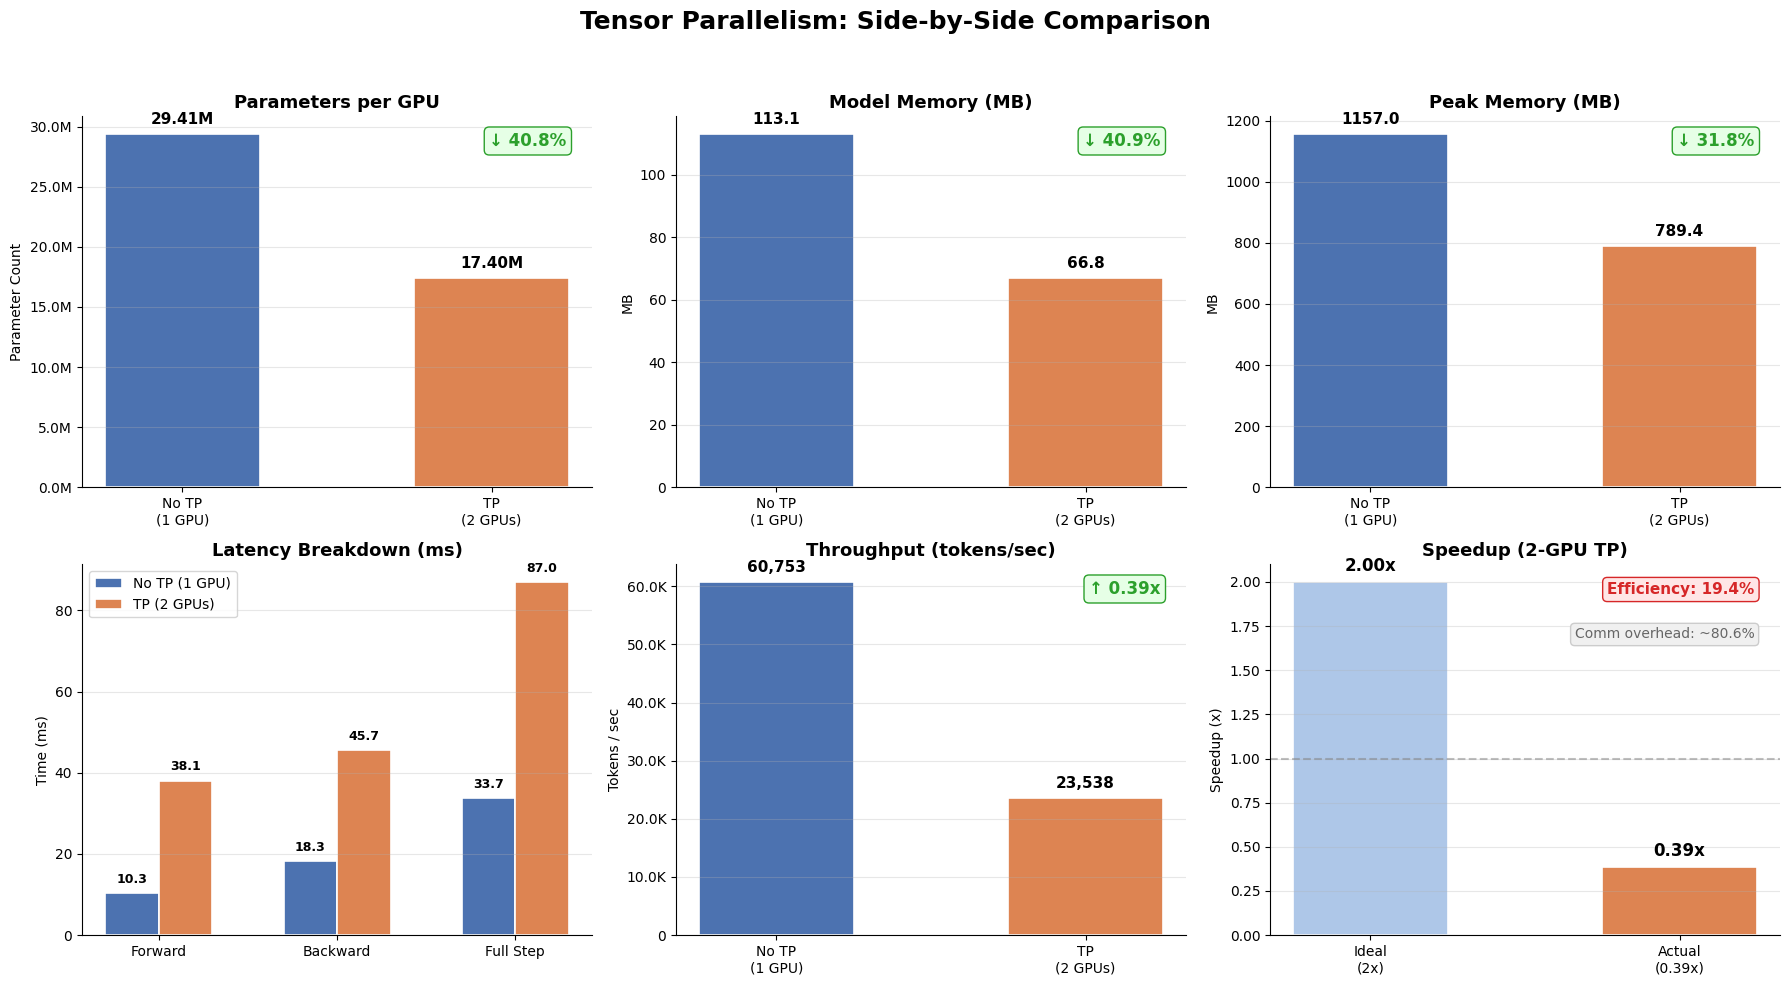

In [17]:
# ================================================================
#  Part 8: Visual Comparison — Bar Charts
# ================================================================
# Paste this as a new cell after Cell 23 (or replace Cell 23)

import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Load results ---
with open('outputs/results_model_gpt.json') as f: no_tp = json.load(f)
with open('outputs/results_model_gpt_tp.json') as f: tp = json.load(f)

ng = tp["num_gpus"]
labels_mode = [f"No TP\n(1 GPU)", f"TP\n({ng} GPUs)"]
colors = ["#4C72B0", "#DD8452"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Tensor Parallelism: Side-by-Side Comparison", fontsize=18, fontweight="bold", y=0.98)

# ── 1. Parameters per GPU ──
ax = axes[0, 0]
vals = [no_tp["params_per_gpu"], tp["params_per_gpu"]]
bars = ax.bar(labels_mode, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title("Parameters per GPU", fontsize=13, fontweight="bold")
ax.set_ylabel("Parameter Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v/1e6:.2f}M", ha="center", va="bottom", fontweight="bold", fontsize=11)
reduction = (1 - tp["params_per_gpu"] / no_tp["params_per_gpu"]) * 100
ax.text(0.95, 0.92, f"↓ {reduction:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=12, color="#2ca02c", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e6ffe6", edgecolor="#2ca02c"))

# ── 2. Model Memory ──
ax = axes[0, 1]
vals = [no_tp["mem_model_mb"], tp["mem_model_mb"]]
bars = ax.bar(labels_mode, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title("Model Memory (MB)", fontsize=13, fontweight="bold")
ax.set_ylabel("MB")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
reduction = (1 - tp["mem_model_mb"] / no_tp["mem_model_mb"]) * 100
ax.text(0.95, 0.92, f"↓ {reduction:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=12, color="#2ca02c", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e6ffe6", edgecolor="#2ca02c"))

# ── 3. Peak Memory ──
ax = axes[0, 2]
vals = [no_tp["mem_peak_mb"], tp["mem_peak_mb"]]
bars = ax.bar(labels_mode, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title("Peak Memory (MB)", fontsize=13, fontweight="bold")
ax.set_ylabel("MB")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
reduction = (1 - tp["mem_peak_mb"] / no_tp["mem_peak_mb"]) * 100
ax.text(0.95, 0.92, f"↓ {reduction:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=12, color="#2ca02c", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e6ffe6", edgecolor="#2ca02c"))

# ── 4. Latency Breakdown (Forward / Backward / Step) ──
ax = axes[1, 0]
x = np.arange(3)
width = 0.3
metrics = ["fwd_ms", "bwd_ms", "step_ms"]
labels_metric = ["Forward", "Backward", "Full Step"]
v_no = [no_tp[m] for m in metrics]
v_tp = [tp[m] for m in metrics]
bars1 = ax.bar(x - width/2, v_no, width, label="No TP (1 GPU)", color=colors[0], edgecolor="white", linewidth=1.2)
bars2 = ax.bar(x + width/2, v_tp, width, label=f"TP ({ng} GPUs)", color=colors[1], edgecolor="white", linewidth=1.2)
ax.set_title("Latency Breakdown (ms)", fontsize=13, fontweight="bold")
ax.set_ylabel("Time (ms)")
ax.set_xticks(x)
ax.set_xticklabels(labels_metric)
ax.legend(fontsize=10)
for bar, v in zip(list(bars1) + list(bars2), v_no + v_tp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(v_no + v_tp)*0.02,
            f"{v:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── 5. Throughput (tokens/sec) ──
ax = axes[1, 1]
vals = [no_tp["tokens_per_sec"], tp["tokens_per_sec"]]
bars = ax.bar(labels_mode, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title("Throughput (tokens/sec)", fontsize=13, fontweight="bold")
ax.set_ylabel("Tokens / sec")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.1f}K" if x >= 1000 else f"{x:.0f}"))
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v:,.0f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
speedup = tp["tokens_per_sec"] / no_tp["tokens_per_sec"]
ax.text(0.95, 0.92, f"↑ {speedup:.2f}x", transform=ax.transAxes,
        ha="right", fontsize=12, color="#2ca02c", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e6ffe6", edgecolor="#2ca02c"))

# ── 6. Speedup & Efficiency ──
ax = axes[1, 2]
step_speedup = no_tp["step_ms"] / tp["step_ms"]
ideal = ng
efficiency = step_speedup / ideal * 100
x = np.arange(2)
vals = [ideal, step_speedup]
bar_labels = [f"Ideal\n({ng}x)", f"Actual\n({step_speedup:.2f}x)"]
bar_colors = ["#aec7e8", colors[1]]
bars = ax.bar(bar_labels, vals, color=bar_colors, width=0.5, edgecolor="white", linewidth=1.2)
ax.set_title(f"Speedup ({ng}-GPU TP)", fontsize=13, fontweight="bold")
ax.set_ylabel("Speedup (x)")
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="No speedup")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
            f"{v:.2f}x", ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.text(0.95, 0.92, f"Efficiency: {efficiency:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=11, color="#d62728", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#ffe6e6", edgecolor="#d62728"))
comm_overhead = 100 - efficiency
ax.text(0.95, 0.80, f"Comm overhead: ~{comm_overhead:.1f}%", transform=ax.transAxes,
        ha="right", fontsize=10, color="#666666",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0", edgecolor="#cccccc"))

# ── Final polish ──
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.savefig("tp_comparison_plots.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
#print("\nPlot saved to tp_comparison_plots.png")